### Principle Component Analysis (2 marks)

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gzip

Importing class Labels and gene symbols to get ids

In [2]:
labels = pd.read_csv("class.tsv", header=None, names=["Class"])["Class"]

cols = pd.read_csv("columns.tsv.gz", sep="\t", comment="#")

genes = cols.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]

ids = genes["ID"].astype(str)

Loading expression data 

In [3]:
with gzip.open("filtered.tsv.gz", "rt") as f:
    expressions = pd.read_csv(f, sep="\t")

expressions.columns = expressions.columns.str.strip()

ReqExpressions = expressions[ids]
ReqExpressions.columns = ["XBP1","GATA3"]

Plotting

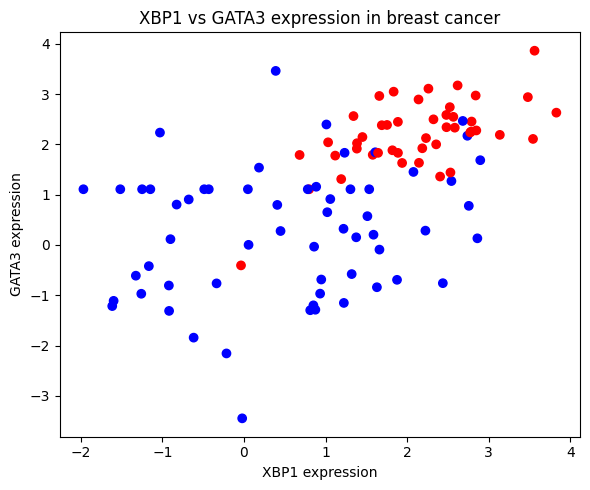

In [4]:
colors = labels.map({1 : "red", 0: "blue"})

plt.figure(figsize=(6,5))
plt.scatter(ReqExpressions["XBP1"], ReqExpressions["GATA3"], c=colors)
plt.xlabel("XBP1 expression")
plt.ylabel("GATA3 expression")
plt.title("XBP1 vs GATA3 expression in breast cancer")
plt.tight_layout()
plt.show()

Now, Let's apply PCA 

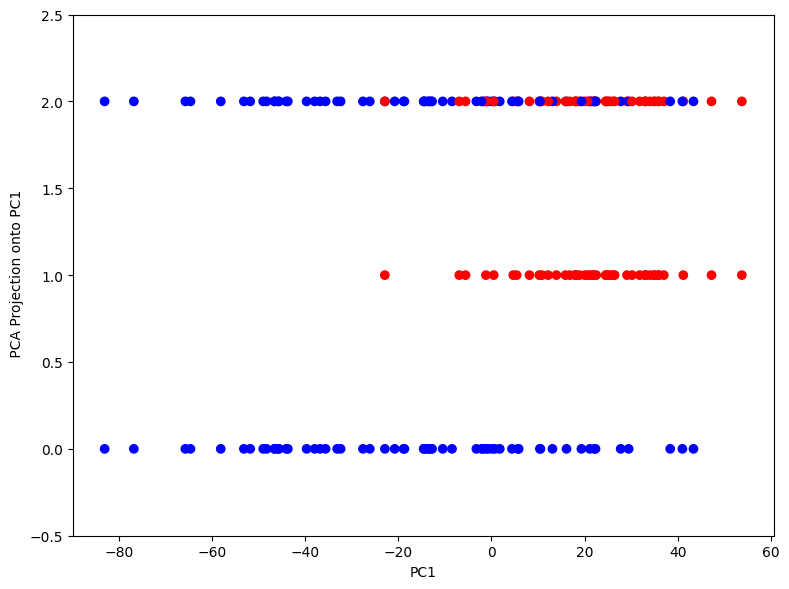

In [5]:
pca = PCA(n_components=1)
pc1d = pca.fit_transform(expressions)

Yaxis = labels.values

pc1d1_extended = np.concatenate([pc1d, pc1d])
Yaxis_extended = np.concatenate([Yaxis, np.full(len(Yaxis), 2)])
colors_extended = np.concatenate([colors, colors])

plt.figure(figsize=(8,6))
plt.scatter(pc1d1_extended, Yaxis_extended, c=colors_extended)
plt.ylim(-0.5, 2.5)
plt.xlabel("PC1")
plt.ylabel(" PCA Projection onto PC1")
plt.tight_layout()
plt.show()